# **Notebook 02** - Limpeza e Tratamento dos Dados

### Objetivo

O objetivo deste notebook é realizar a limpeza e o tratamento do conjunto de dados consolidado da Cyclistic, preparando os dados para as etapas de análise exploratória, consultas SQL e visualização no Power BI.

Nesta etapa serão investigados possíveis problemas de qualidade e consistência dos dados, garantindo que as informações utilizadas nas análises sejam adequadas e confiáveis.

### Etapas

Neste notebook serão realizadas as seguintes etapas:

**1. Importação das bibliotecas necessárias;**<br>
**2. Carregamento do dataset consolidado;**<br>
**3. Inspeção Inicial com Sweetviz**<br>
**4. Verificação dos tipos de dados;**<br>
**5. Conversão e padronização das variáveis de data e hora;**<br>
**6. Identificação e tratamento de valores ausentes;**<br>
**7. Identificação e tratamento de registros duplicados;**<br>
**8. Verificação de inconsistências nos dados e valores inválidos;**<br>
**9. Criação de novas variáveis para análise;**<br>
**10. Identificação e tratamento de outliers;**<br>
**11. Validação do dataset após o tratamento;**<br>
**12. Salvamento do dataset processado.**

---

## 1. Importação das Bibliotecas

In [1]:
# Imports

import numpy as np
import pandas as pd
import seaborn as sns
import sweetviz as sv
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

---

## 2. Carregamento dos Dados

In [63]:
# Carrega o Dataset e cria o DataFrame

df = pd.read_csv("../data/processed/cyclistic_202509_202608.csv")

---

## 3. Inspeção Inicial com Sweetviz

                                             |          | [  0%]   00:00 -> (? left)

findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfo


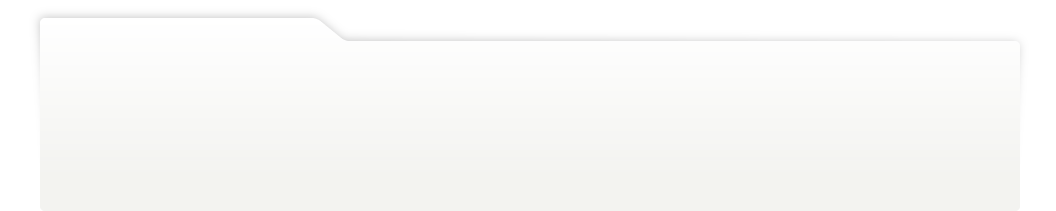
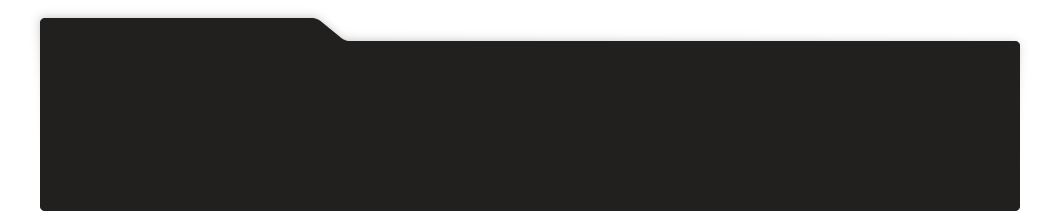
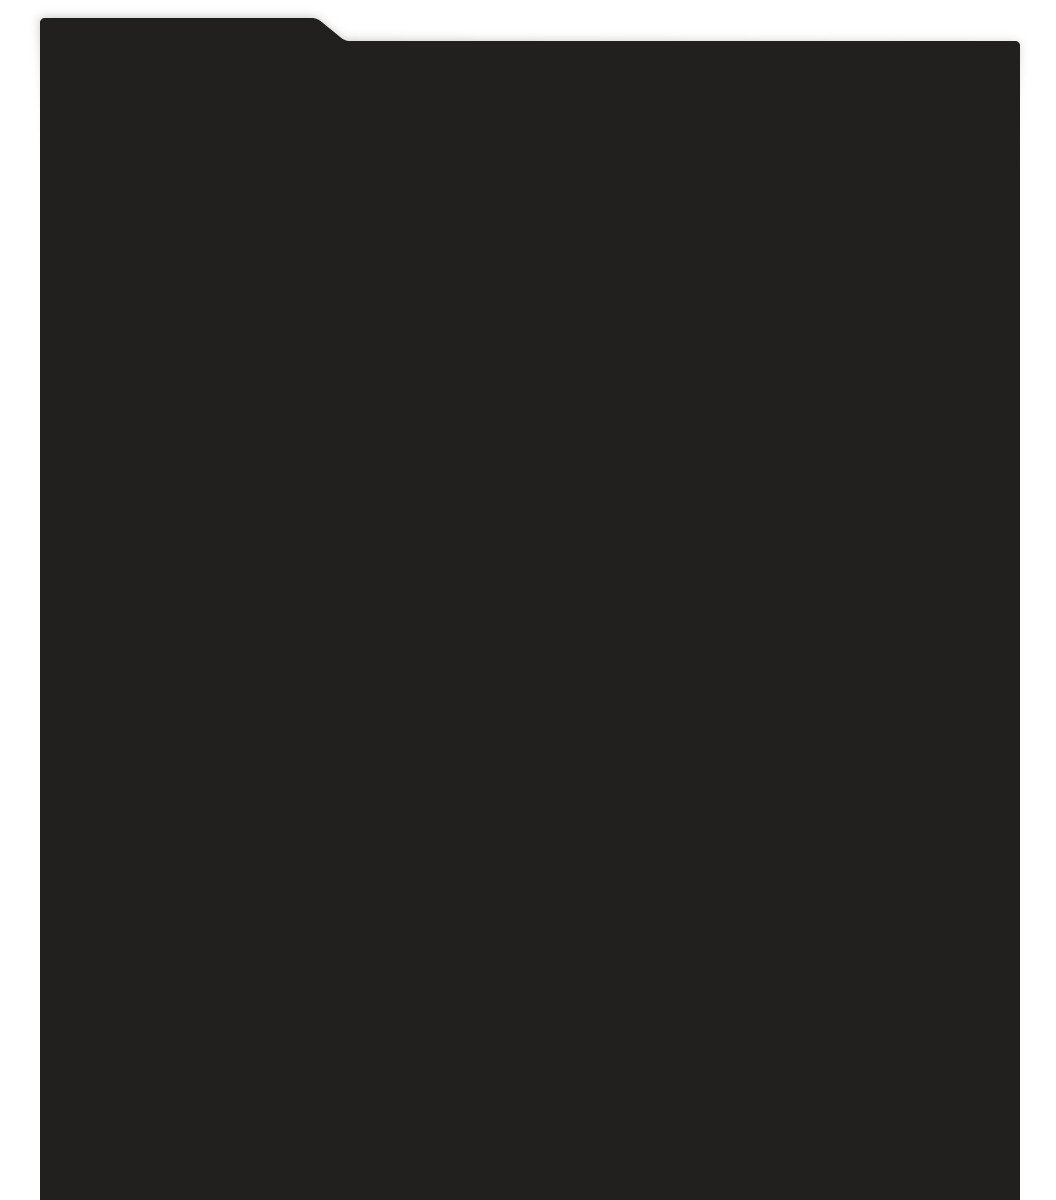
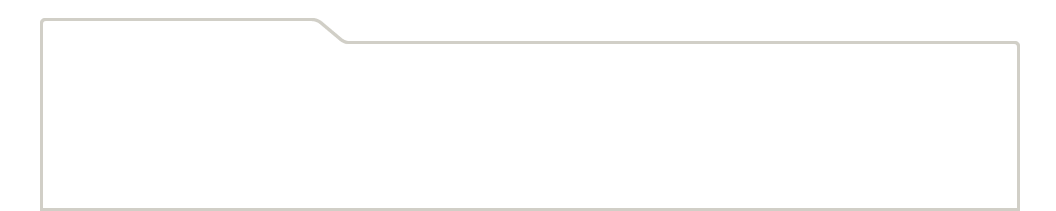
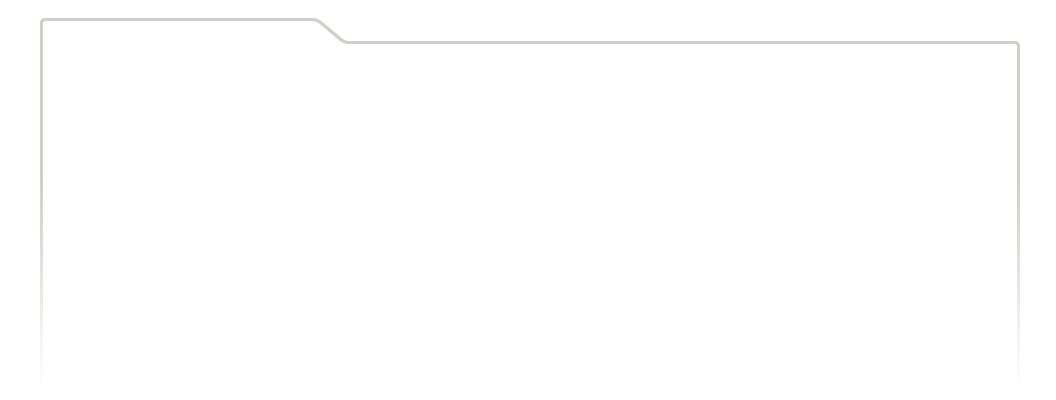
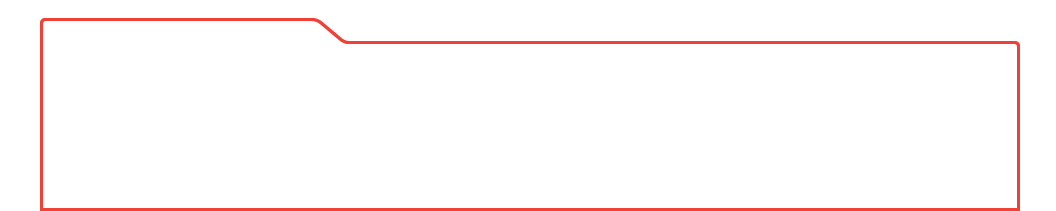
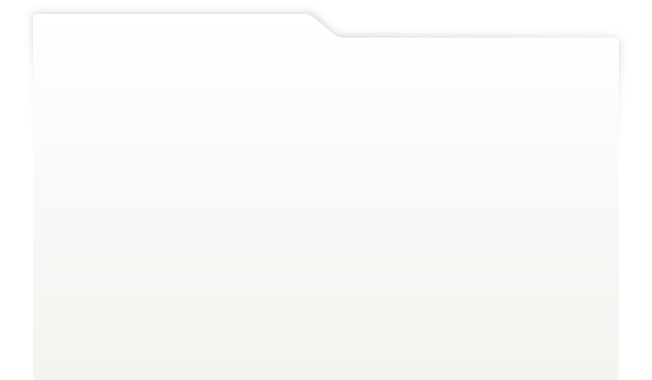
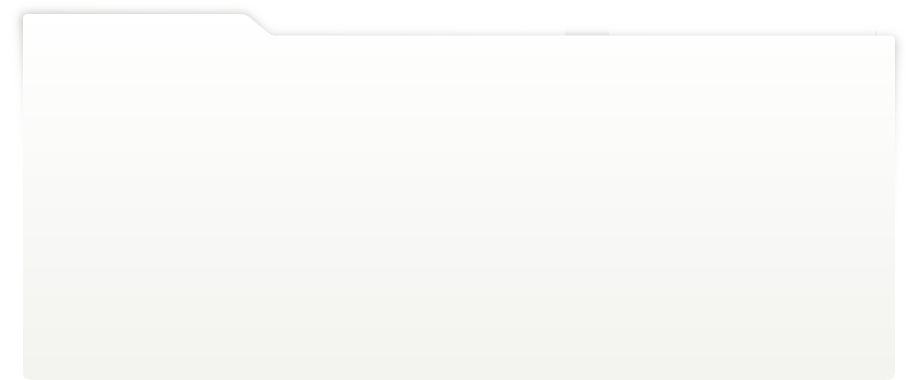
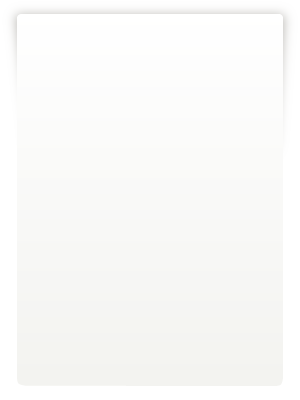
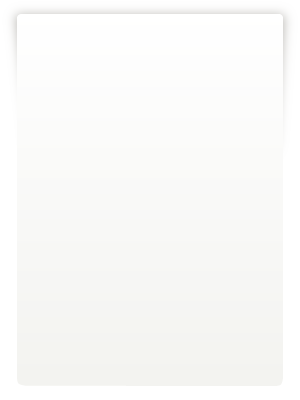
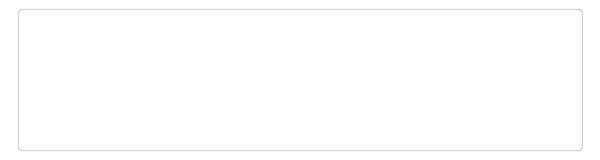
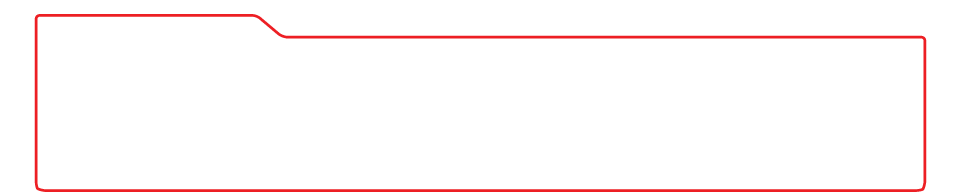
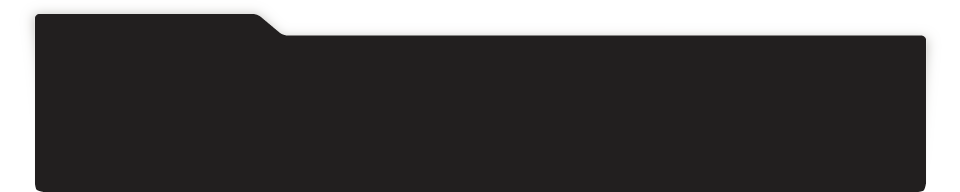
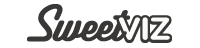
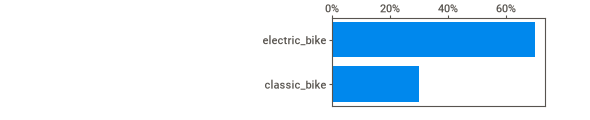
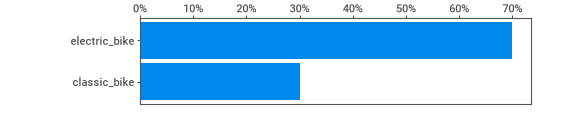
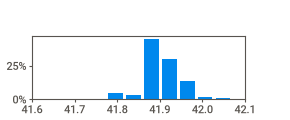
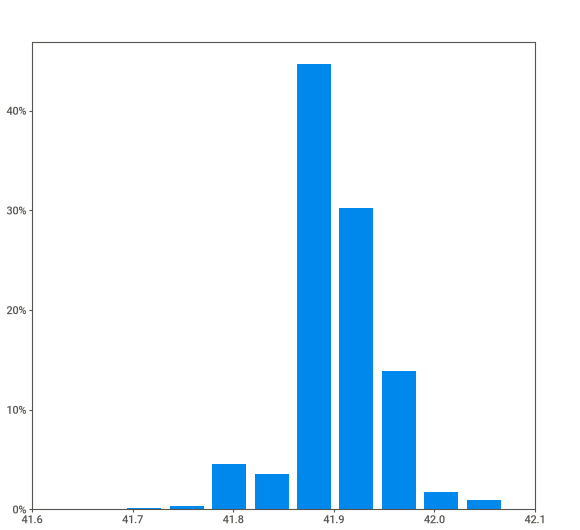
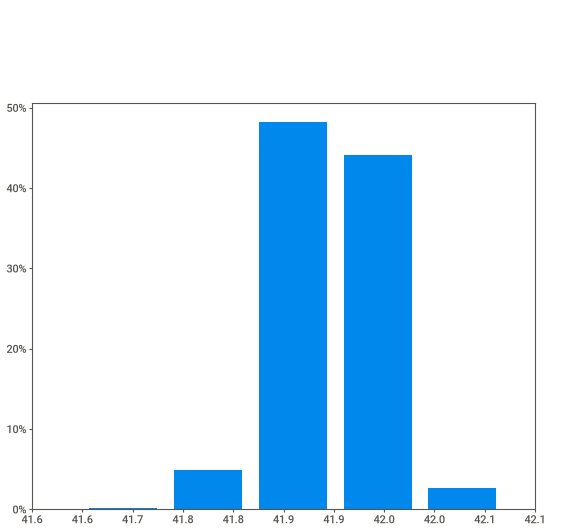
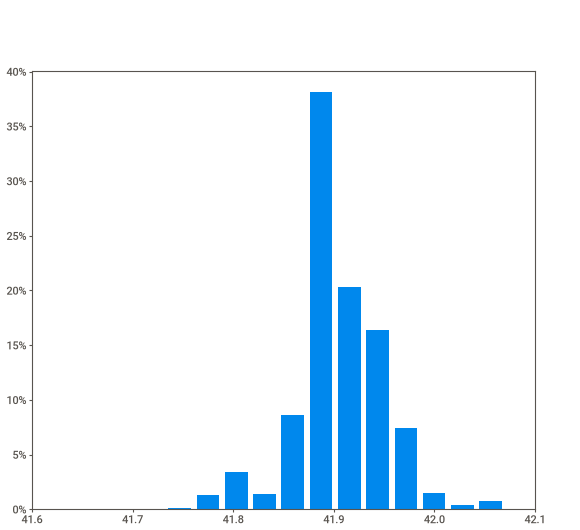
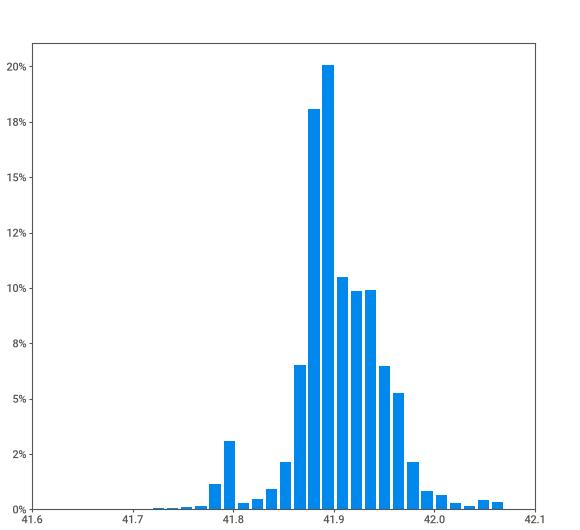
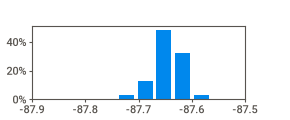
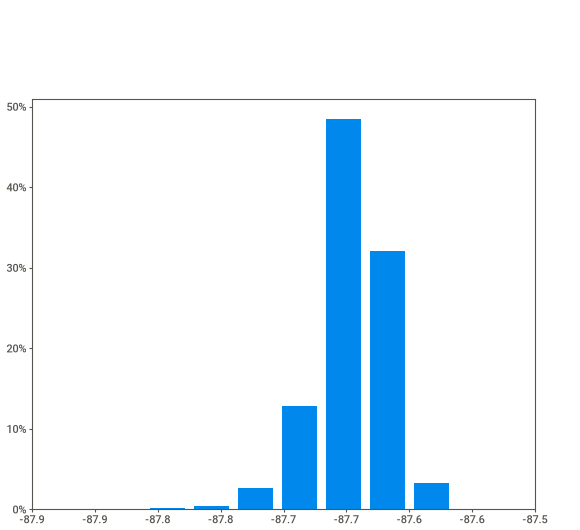
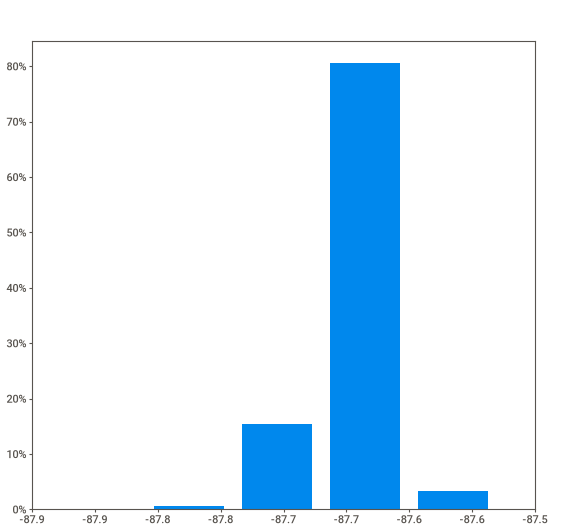
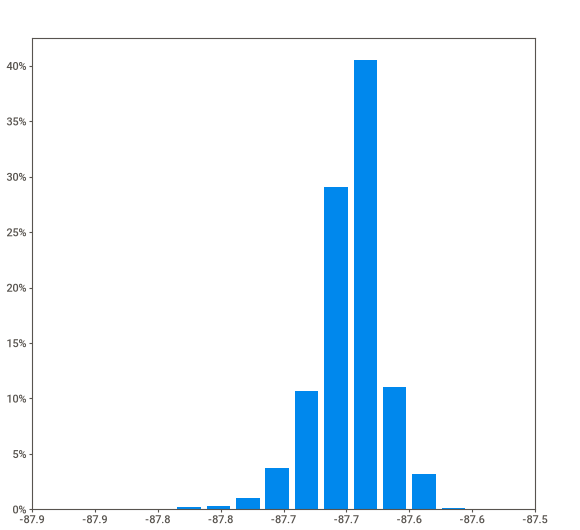
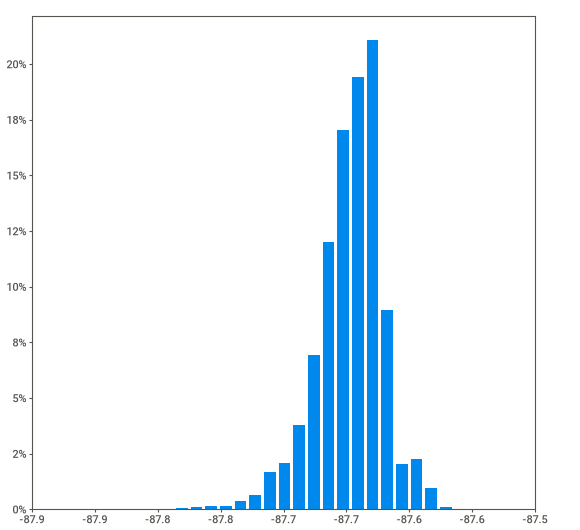
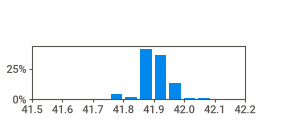
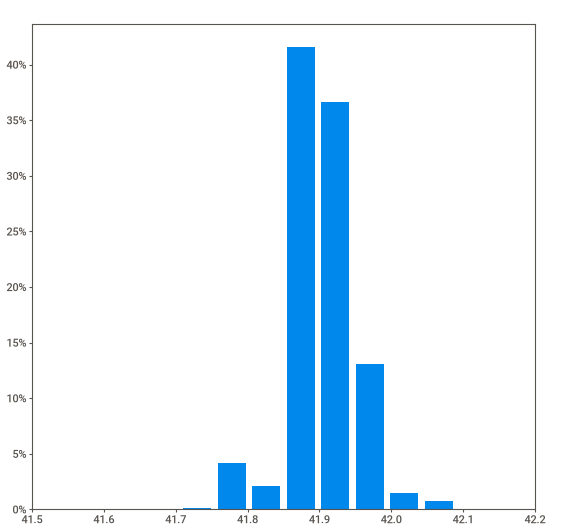
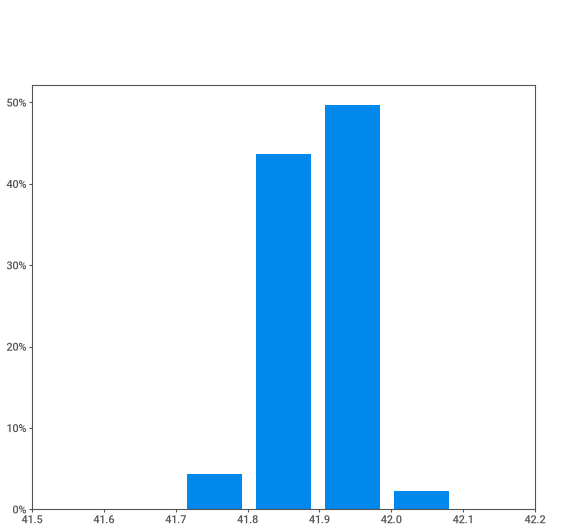
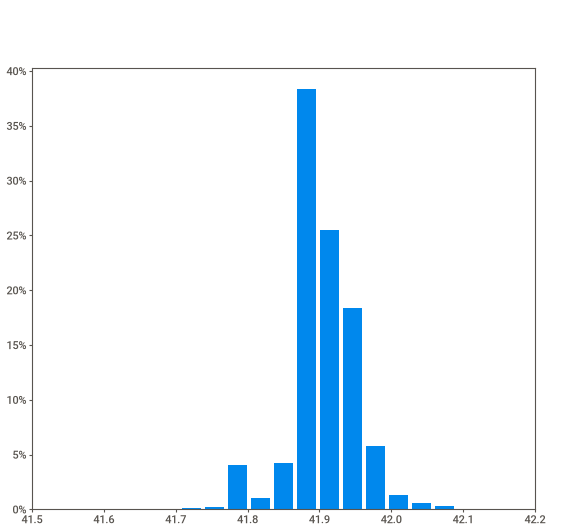
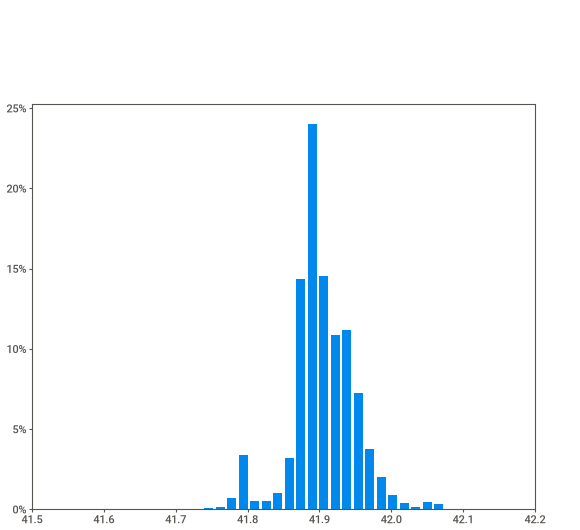
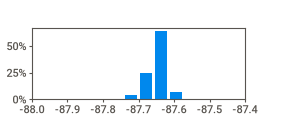
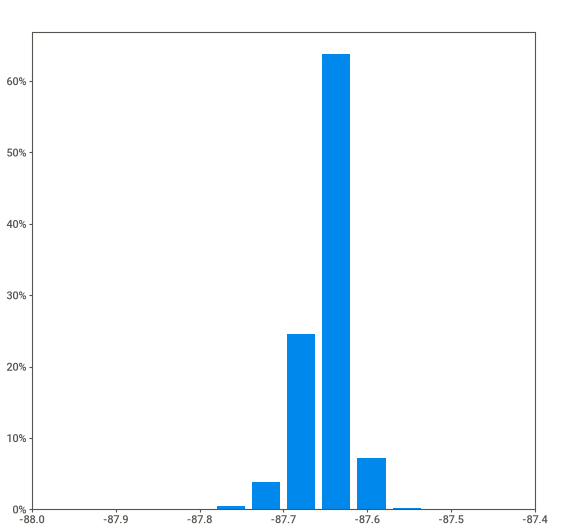
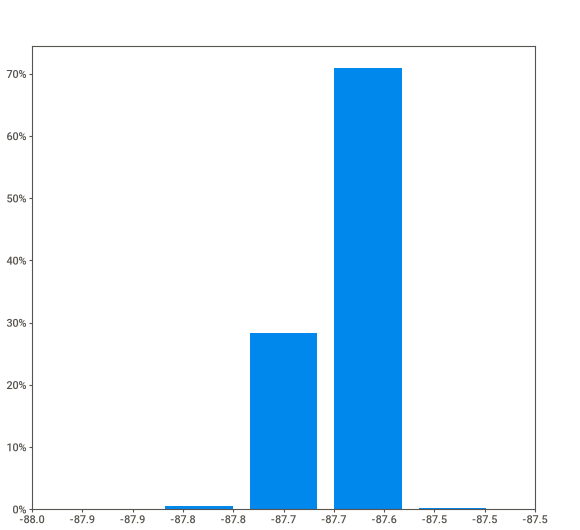
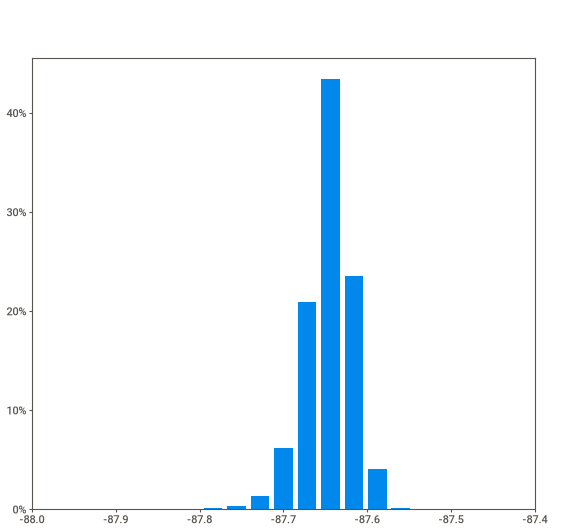
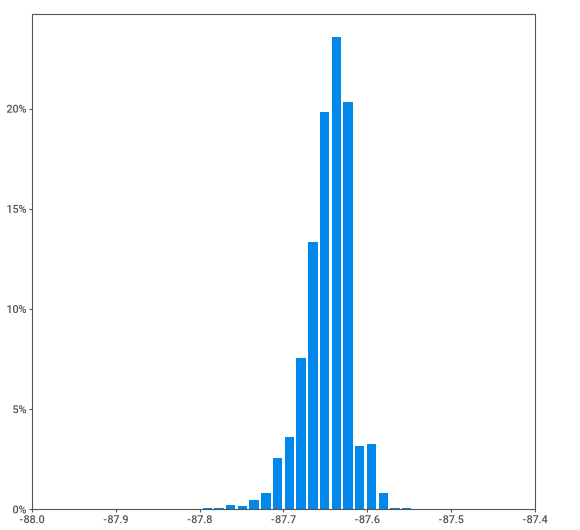
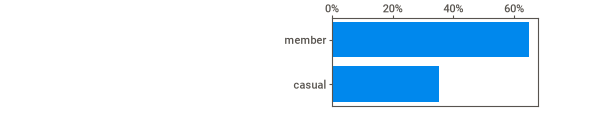
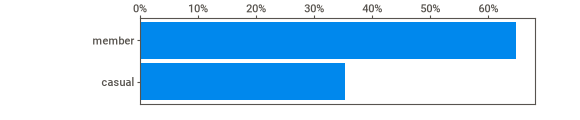
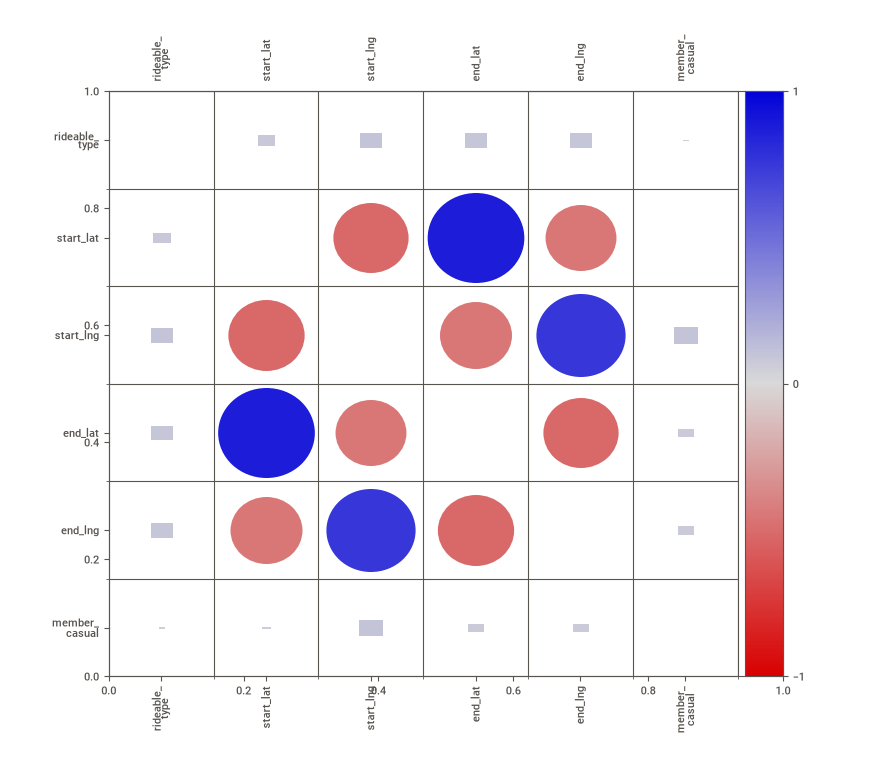
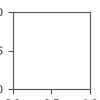

In [3]:
# Gera um relatório geral de uma amostra do DataFrame

df_sample = df.sample(100_000, random_state=42)

report = sv.analyze(df_sample)

report.show_notebook()

---

## 4. Verificação dos Tipos de Dados

In [64]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6115982 entries, 0 to 6115981
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 606.6 MB


#### `started_at` e `ended_at`

As colunas `started_at` e `ended_at` estão inicialmente armazenadas como `str`. Elas serão convertidas para o tipo `datetime`, pois representam datas e horários e serão utilizadas posteriormente para criar variáveis temporais, como data, hora, dia da semana e mês, além de calcular a duração das viagens.

---

## 5. Conversão e padronização das variáveis de data e hora

In [ ]:
# Convertendo as colunas para datetime

df["started_at"] = pd.to_datetime(
    df["started_at"],
    errors="coerce"
)

df["ended_at"] = pd.to_datetime(
    df["ended_at"],
    errors="coerce"
)

In [ ]:
# Checando se a conversão funcionou

df[["started_at", "ended_at"]].dtypes

started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

---

## 6. Análise de Valores Ausentes

### 6.1 Relatótio de Dados Ausentes

In [68]:
# Conta o número de valores ausentes com base no tipo da váriavel

def missing_data_type(column):

    series = df[column]

    if pd.api.types.is_numeric_dtype(series):
        return series.isna().sum()

    elif pd.api.types.is_datetime64_any_dtype(series):
        return series.isna().sum()

    elif pd.api.types.is_string_dtype(series) or series.dtype == "object":
        return (
            series.isna().sum()
            + series.astype("string").str.strip().eq("").sum()
        )

    return 0

In [ ]:
# Cria um DataFrame de relatório sobre os valores ausentes do DataFrame principal
def df_report_missing(df):
    dict_nulls = {}

    for column in df.columns:

        dict_nulls[column] = {
            "Colunas" : column,
            "Valores" : len(df[column]),
            "Valores Faltantes" : missing_data_type(column),
            "Perda de Valores (%)" : (df[column].isnull().sum() / len(df[column])) * 100 
        }

    report = pd.DataFrame(dict_nulls.values())

    return report.sort_values(
        "Valores Faltantes",
        ascending=False
    )

In [70]:
# Exibe o relatório de dados ausentes de forma estilizada para melhor visualização

def table_report_missing(report): 
    display(
        report.style
        .hide(axis="index")
        .set_caption("Relatório de Valores Ausentes")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "10px 0")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#2F4F4F"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "8px"),
                    ("text-align", "left")
                ]
            }
        ])
        .format({
            "Valores": lambda x: f"{x:,.0f}".replace(",", "."),
            "Valores Faltantes": lambda x: f"{x:,.0f}".replace(",", "."), 
            "Perda de Valores (%)": "{:.2f}%"
        })
        .bar(
            subset=["Perda de Valores (%)"],
            cmap="Reds"
        )
        .background_gradient(
            subset=["Valores Faltantes"],
            cmap="Reds"
        )
    )

In [71]:
report_missing_data = df_report_missing(df)
table_report_missing(report_missing_data)

Colunas,Valores,Valores Faltantes,Perda de Valores (%)
end_station_name,6.115.982,1.349.937,22.07%
end_station_id,6.115.982,1.349.937,22.07%
start_station_id,6.115.982,1.285.406,21.02%
start_station_name,6.115.982,1.285.406,21.02%
end_lat,6.115.982,5.426,0.09%
end_lng,6.115.982,5.426,0.09%
started_at,6.115.982,0,0.00%
rideable_type,6.115.982,0,0.00%
ride_id,6.115.982,0,0.00%
ended_at,6.115.982,0,0.00%


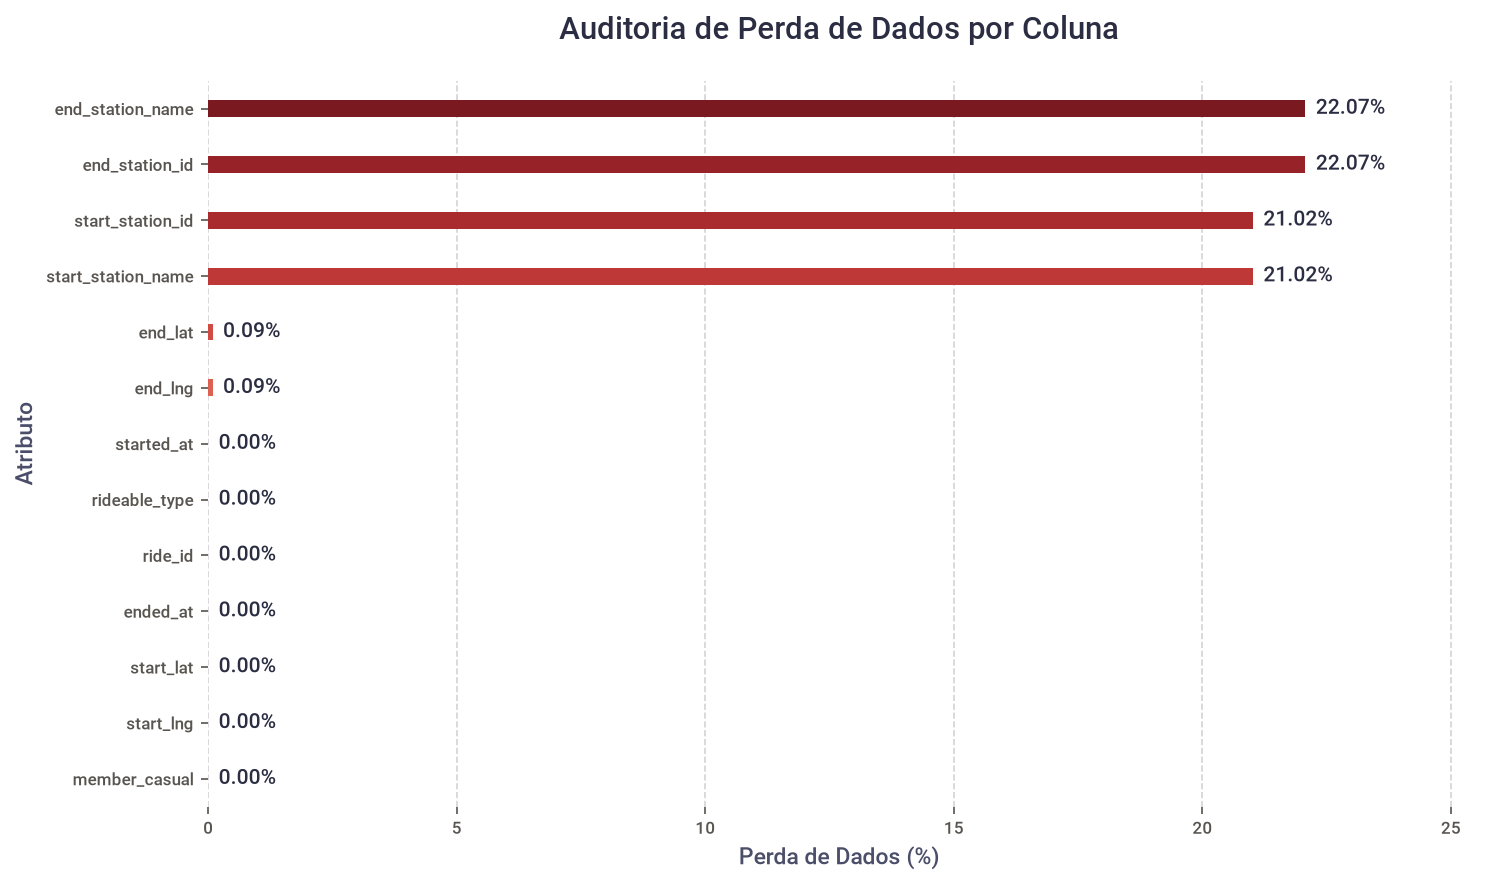

In [ ]:
# Exibe gráfico do relatório de dados ausentes

plt.figure(figsize=(10,6), dpi=150)

plt.gca().set_axisbelow(True)
plt.grid(axis="x", linestyle="--", alpha=0.4, color="#9A8C98")

ax = sns.barplot(
    x="Perda de Valores (%)",
    y="Colunas",
    data=report_missing_data,
    hue="Colunas",
    palette="Reds_r",
    legend=False,
    width=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=5,
        fontsize=10,
        fontweight="semibold",
        color="#2B2D42",
        fmt="%.2f%%"
    )

plt.title(
    "Auditoria de Perda de Dados por Coluna", 
    fontsize=15, 
    fontweight="bold", 
    color="#2B2D42", 
    pad=20
)
plt.xlabel("Perda de Dados (%)", fontsize=11, fontweight="semibold", color="#4A4E69")
plt.ylabel("Atributo", fontsize=11, fontweight="semibold", color="#4A4E69")
plt.xlim(0, report_missing_data["Perda de Valores (%)"].max() * 1.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### 6.2 Checagem Individual de Colunas com Valores Ausentes

In [ ]:
# Amostra dos dados ausentes da coluna "end_station_name"

df[df["end_station_name"].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [ ]:
# Amostra dos dados ausentes da coluna "end_station_id"

df[df["end_station_id"].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [200]:
# Amostra dos dados ausentes da coluna "start_station_name"

df[df["start_station_name"].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week,day_of_week_name,hour


In [ ]:
# Amostra dos dados ausentes da coluna "start_station_id"

df[df["start_station_id"].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [ ]:
# Amostra dos dados ausentes da coluna "end_lat"

df[df["end_lat"].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
66846,9905C909001B3F73,classic_bike,2025-09-06 09:50:16.336,2025-09-07 10:50:06.364,Dearborn Pkwy & Delaware Pl,CHI00306,NaN,NaN,41.898969,-87.629912,NaN,NaN,casual
67192,DE4A219B1205788C,classic_bike,2025-09-16 15:58:46.084,2025-09-17 16:58:38.814,State St & 54th St,CHI01078,NaN,NaN,41.796642,-87.625923,NaN,NaN,casual
67274,CCC64EB0C9099A7F,classic_bike,2025-09-18 08:59:49.629,2025-09-19 09:59:45.331,Knox Ave & Marquette Ave,CHI01847,NaN,NaN,41.771140,-87.737740,NaN,NaN,casual
67342,AAE605E4EE8631DE,classic_bike,2025-09-26 18:34:57.900,2025-09-27 19:34:54.517,Pulaski Rd & 51st St,CHI01876,NaN,NaN,41.800434,-87.724750,NaN,NaN,casual
67344,9238F50379FBCC62,classic_bike,2025-09-26 12:22:42.614,2025-09-27 13:22:39.022,Winthrop Ave & Lawrence Ave,CHI00391,NaN,NaN,41.968812,-87.657659,NaN,NaN,casual


In [ ]:
# Amostra dos dados ausentes da coluna "end_lng"

df[df["end_lng"].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
66846,9905C909001B3F73,classic_bike,2025-09-06 09:50:16.336,2025-09-07 10:50:06.364,Dearborn Pkwy & Delaware Pl,CHI00306,NaN,NaN,41.898969,-87.629912,NaN,NaN,casual
67192,DE4A219B1205788C,classic_bike,2025-09-16 15:58:46.084,2025-09-17 16:58:38.814,State St & 54th St,CHI01078,NaN,NaN,41.796642,-87.625923,NaN,NaN,casual
67274,CCC64EB0C9099A7F,classic_bike,2025-09-18 08:59:49.629,2025-09-19 09:59:45.331,Knox Ave & Marquette Ave,CHI01847,NaN,NaN,41.771140,-87.737740,NaN,NaN,casual
67342,AAE605E4EE8631DE,classic_bike,2025-09-26 18:34:57.900,2025-09-27 19:34:54.517,Pulaski Rd & 51st St,CHI01876,NaN,NaN,41.800434,-87.724750,NaN,NaN,casual
67344,9238F50379FBCC62,classic_bike,2025-09-26 12:22:42.614,2025-09-27 13:22:39.022,Winthrop Ave & Lawrence Ave,CHI00391,NaN,NaN,41.968812,-87.657659,NaN,NaN,casual


### 6.3 Comparação Entre Colunas com Dados Ausentes

In [ ]:
# Localiza todas as colunas que têm valores ausentes

cols_missing_data = report_missing_data[
    report_missing_data["Valores Faltantes"] != 0
]["Colunas"]

In [80]:
# Armazena os índices dos valores ausentes de cada coluna

null_indexes = {
    col: set(df.index[df[col].isnull()])
    for col in cols_missing_data
}

In [81]:
# Compara se os registros ausentes são exatamente iguais

for i, col1 in enumerate(cols_missing_data):

    for col2 in cols_missing_data[i + 1:]:

        if null_indexes[col1] == null_indexes[col2]:

            print(
                f"`{col1}` e `{col2}` possuem valores ausentes "
                "nos mesmos registros."
            )

`end_station_name` e `end_station_id` possuem valores ausentes nos mesmos registros.
`start_station_id` e `start_station_name` possuem valores ausentes nos mesmos registros.
`end_lat` e `end_lng` possuem valores ausentes nos mesmos registros.


In [82]:
# Compara a contenção dos valores ausentes

if null_indexes["end_lat"].issubset(
    null_indexes["end_station_name"]
):
    print(
        "Todos os valores ausentes de `end_lat` "
        "estão contidos nos de `end_station_name`."
    )

if null_indexes["start_station_id"].issubset(
    null_indexes["end_station_name"]
):
    print(
        "Todos os valores ausentes de `start_station_name` "
        "estão contidos nos de `end_station_name`."
    )

if null_indexes["end_lat"].issubset(
    null_indexes["start_station_id"]
):
    print(
        "Todos os valores ausentes de `end_lat"
        "estão contidos nos de `start_station_name`."
    )

Todos os valores ausentes de `end_lat` estão contidos nos de `end_station_name`.


In [83]:
# Compara os registros ausentes das estações de início e fim

start_station_null = null_indexes["start_station_name"]
end_station_null = null_indexes["end_station_name"]

intersection = start_station_null & end_station_null

print(
    f"Registros com `start_station` e `end_station` ausentes: "
    f"{len(intersection):,}".replace(",", ".")
)

Registros com `start_station` e `end_station` ausentes: 577.879


#### Análise dos valores ausentes

`start_station_name`/`start_station_id` e `end_station_name`/`end_station_id` possuem ausências nos mesmos registros e serão analisados em conjunto.

`end_station_name` e `end_station_id` possuem **1.349.937** ausências, enquanto `end_lat` e `end_lng` possuem apenas **5.426**, todas contidas nas ausências da estação de destino. Dessa forma, as coordenadas disponíveis poderão ser utilizadas para tentar recuperar as estações de destino.

A mesma abordagem poderá ser aplicada às estações de início, utilizando `start_lat` e `start_lng` para tentar recuperar as informações ausentes.

Também foram identificados **577.879 registros** com as estações de início e término simultaneamente ausentes.


### 6.4 Investigação das Cordenadas e suas Estações Correspondentes

#### 6.4.1 Comparação Entre Ecoordenadas de Inicio e de Fim (start e end)

In [84]:
# Criar tabelas com coordenada + nome da estação


start_coords = (
    df[["start_lat", "start_lng", "start_station_name"]]
    .dropna(subset=["start_lat", "start_lng", "start_station_name"])
    .drop_duplicates()
)

end_coords = (
    df[["end_lat", "end_lng", "end_station_name"]]
    .dropna(subset=["end_lat", "end_lng", "end_station_name"])
    .drop_duplicates()
)

In [85]:
# Quantidade de coordenadas únicas

start_unique = start_coords[["start_lat", "start_lng"]].drop_duplicates()
end_unique = end_coords[["end_lat", "end_lng"]].drop_duplicates()

print("Coordenadas únicas:")
print(f"START: {len(start_unique):,}")
print(f"END:   {len(end_unique):,}")

Coordenadas únicas:
START: 133,703
END:   2,143


In [86]:
# Quantos nomes diferentes cada coordenada possui?

start_consistency = (
    start_coords
    .groupby(["start_lat", "start_lng"])["start_station_name"]
    .nunique()
    .reset_index(name="qtd_nomes")
)

end_consistency = (
    end_coords
    .groupby(["end_lat", "end_lng"])["end_station_name"]
    .nunique()
    .reset_index(name="qtd_nomes")
)


In [87]:
# Classifica as coordenadas por nível de consistência

def classificar_consistencia(qtd):
    if qtd == 1:
        return "Consistente"
    else:
        return "Ambígua"


start_consistency["consistencia"] = (
    start_consistency["qtd_nomes"]
    .apply(classificar_consistencia)
)

end_consistency["consistencia"] = (
    end_consistency["qtd_nomes"]
    .apply(classificar_consistencia)
)

In [88]:
# Resumo START

start_summary = (
    start_consistency["consistencia"]
    .value_counts()
    .rename_axis("consistencia")
    .reset_index(name="quantidade")
)

start_summary["percentual"] = (
    start_summary["quantidade"]
    / len(start_consistency)
    * 100
)

In [89]:
# 6. Resumo END

end_summary = (
    end_consistency["consistencia"]
    .value_counts()
    .rename_axis("consistencia")
    .reset_index(name="quantidade")
)

end_summary["percentual"] = (
    end_summary["quantidade"]
    / len(end_consistency)
    * 100
)

In [90]:
#  Mostra os resultados

print("\n--- START ---")
print(start_summary)

print("\n--- END ---")
print(end_summary)


--- START ---
  consistencia  quantidade  percentual
0  Consistente      133639   99.952133
1      Ambígua          64    0.047867

--- END ---
  consistencia  quantidade  percentual
0  Consistente        2091   97.573495
1      Ambígua          52    2.426505


##### Serão utilizadas as coordenadas *START* como referência

- As coordenadas de início (`start_lat` e `start_lng`) apresentaram maior consistência na identificação das estações do que as coordenadas de destino (`end_lat` e `end_lng`). Por isso, serão utilizadas como referência para auxiliar no preenchimento das coordenadas de destino ausentes.

- Essa escolha não significa que as coordenadas *START* sejam sempre exatas ou imutáveis. Uma mesma estação pode apresentar pequenas variações nas coordenadas ao longo dos registros e, em alguns casos, valores atípicos. Por isso, será utilizada uma coordenada representativa da estação, em vez de assumir que todas as coordenadas observadas são idênticas.

#### 6.4.2 `start_lat`e `start_lng`

In [91]:
# Criar uma tabela de referência com coordenadas por estação 

start_station_reference = (
    df[
        df["start_lat"].notna()
        & df["start_lng"].notna()
        & df["start_station_name"].notna()
    ][
        ["start_lat", "start_lng", "start_station_name", "start_station_id"]
    ]
    .drop_duplicates()
)

start_station_reference.head()

,start_lat,start_lng,start_station_name,start_station_id
8,41.888960,-87.649730,Peoria St & Kinzie St,CHI02098
53,41.961524,-87.691177,Campbell Ave & Montrose Ave,CHI00214
148,41.943034,-87.687288,Western Ave & Roscoe St,CHI00614
175,41.922695,-87.697153,California Ave & Milwaukee Ave,CHI00307
180,41.862378,-87.651062,Morgan Ave & 14th Pl,CHI00261


In [92]:
## Exibe quantas coordenadas diferentes existem 

start_coordinate_counts = (
    df[
        df["start_lat"].notna()
        & df["start_lng"].notna()
    ]
    .groupby(["start_lat", "start_lng"])
    .size()
    .sort_values(ascending=False)
)

start_coordinate_counts.head(20)

start_lat  start_lng 
41.892278  -87.612043    68029
41.890000  -87.630000    49570
41.880000  -87.640000    47154
           -87.630000    45363
41.910000  -87.630000    42013
41.900000  -87.630000    38082
41.880958  -87.616743    37971
41.890000  -87.620000    36236
41.900960  -87.623777    34599
41.911722  -87.626804    32506
41.890000  -87.640000    29760
41.896617  -87.628579    29438
41.882409  -87.639767    29357
41.940000  -87.650000    28505
41.883380  -87.641170    27836
41.912133  -87.634656    27800
41.926277  -87.630834    26739
41.903222  -87.634324    26486
41.930000  -87.650000    26455
41.940000  -87.640000    25891
dtype: int64

In [93]:
# Exibe quantas coordenadas correspondem a 1 ou mais nomes de estações

start_coordinate_station = (
    df[
        df["start_lat"].notna()
        & df["start_lng"].notna()
        & df["start_station_name"].notna()
    ]
    .groupby(["start_lat", "start_lng"])["start_station_name"]
    .nunique()
)

start_coordinate_station.value_counts().sort_index()

start_station_name
1    133639
2        57
3         6
4         1
Name: count, dtype: int64

In [94]:
# Calcula a quantidade de coordenadas que referem-se a cada nome de estação

station_check = (
    start_station_reference
    .groupby("start_station_name")
    .agg(
        qtd_coordenadas=("start_lat", "nunique"),
        qtd_ids=("start_station_id", "nunique")
    )
    .reset_index()
)

In [95]:
# Exibe o numero de coordenadas por estação

station_check["qtd_coordenadas"].value_counts().sort_index()

qtd_coordenadas
1       606
2       226
3       127
4        74
5        49
       ... 
880       1
906       1
978       1
1047      1
1359      1
Name: count, Length: 333, dtype: int64

In [96]:
# Exibe quantas coordenadas correspondem a 1 ou mais ids de estações

station_check["qtd_ids"].value_counts().sort_index()

qtd_ids
1    1929
2      62
3       1
Name: count, dtype: int64

In [97]:
# Filtra o station_check para encontrar apenas os nomes de estação que têm, 
# ao mesmo tempo, mais de uma coordenada e mais de um ID

station_check[
    (station_check["qtd_coordenadas"] > 1) &
    (station_check["qtd_ids"] > 1)
]

,start_station_name,qtd_coordenadas,qtd_ids
19,Albany Ave & 16th St,16,2
21,Albany Ave & Belmont Ave,49,2
27,Archer Ave & 43rd St,2,2
135,California Ave & Winona St,42,2
145,Campbell Ave & Augusta Blvd,147,2
...,...,...,...
1943,Western Ave & Gunnison St,83,2
1945,Western Ave & Lake St,11,2
1956,Whipple St & Roosevelt Rd,17,2
1960,Wilton Ave & Diversey Pkwy,105,2


##### Será utilizado o *ID* em vez do *nome*

- O `station_id` será utilizado como chave principal para identificar as estações, pois apresentou maior estabilidade do que o *nome* da estação. A maioria dos nomes está associada a um único *ID*, enquanto um mesmo *nome* pode aparecer com diferentes coordenadas e, em alguns casos, diferentes *IDs*.

- Ainda existem exceções, portanto o `station_id` não será tratado como uma chave perfeitamente imutável. A referência das coordenadas será construída considerando essa variação e evitando assumir uma relação rígida de uma estação para uma única coordenada.

#### 6.4.3 Criando Coordenada de Referência por `start_station_id`

In [98]:
# Pega, para cada ID, a coordenada START que aparece com maior frequência

start_coord_reference = (
    df.dropna(subset=["start_station_id", "start_lat", "start_lng"])
    .groupby(["start_station_id", "start_lat", "start_lng"])
    .size()
    .reset_index(name="qtd")
    .sort_values(
        ["start_station_id", "qtd"],
        ascending=[True, False]
    )
    .drop_duplicates("start_station_id")
)

In [99]:
start_coord_reference.head()

,start_station_id,start_lat,start_lng,qtd
0,CHI02331,41.884390,-87.635170,643
1,000-CHI01831,41.877161,-87.706134,9
38,CHI00005,41.912616,-87.681469,4438
141,CHI00213,41.815491,-87.702441,21
154,CHI00214,41.961524,-87.691177,3567


In [100]:
# Pega, para cada ID, a coordenada END que aparece com maior frequência

end_coord_reference = (
    df.dropna(subset=["end_station_id", "end_lat", "end_lng"])
    .groupby(["end_station_id", "end_lat", "end_lng"])
    .size()
    .reset_index(name="qtd")
    .sort_values(
        ["end_station_id", "qtd"],
        ascending=[True, False]
    )
    .drop_duplicates("end_station_id")
)

In [101]:
# Compara com as duas referências

coordinate_validation = start_coord_reference.merge(
    end_coord_reference,
    left_on="start_station_id",
    right_on="end_station_id",
    how="inner"
)

In [102]:
# Verifica se as coordenadas predominantes são iguais

coordinate_validation["mesma_coordenada"] = (
    (coordinate_validation["start_lat"] == coordinate_validation["end_lat"]) &
    (coordinate_validation["start_lng"] == coordinate_validation["end_lng"])
)

In [103]:
coordinate_validation["mesma_coordenada"].value_counts()

mesma_coordenada
True     1977
False       3
Name: count, dtype: int64

##### A coordenada predominante de START será usada como referência para a estação.

- A coordenada **START** mais frequente por `station_id` foi utilizada como referência para identificar as estações. Essa escolha foi validada comparando a coordenada predominante de **START** com a coordenada predominante de **END** para os mesmos IDs, obtendo concordância em **1.977 de 1.980** estações analisadas (**99,85%**).

- Essa referência foi utilizada para auxiliar na recuperação dos valores ausentes de identificação das estações, sem substituir valores que já estavam preenchidos.

### 6.5 Tratando Valores Ausentes

####  6.5.1 Uso das Coordenadas Prodiminantes de START

In [104]:
# Cria uma referência com a coordenada e o nome mais frequentes de cada estação,
# usando o start_station_id como chave para identificar cada estação.

station_reference = (
    df.dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "start_lat",
            "start_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "start_lat",
            "start_lng"
        ]
    )
    .size()
    .reset_index(name="qtd")
    .sort_values("qtd", ascending=False)
    .drop_duplicates("start_station_id")
)

In [105]:
# Cria uma estrutura de busca espacial com as coordenadas das estações
# para encontrar rapidamente a estação mais próxima de cada coordenada.

tree = cKDTree(
    station_reference[
        ["start_lat", "start_lng"]
    ].to_numpy()
)

In [106]:
# Seleciona os registros que possuem as coordenadas START,
# mas estão sem o ID da estação.

mask_start = (
    df["start_station_id"].isna()
    & df["start_lat"].notna()
    & df["start_lng"].notna()
)

dist_start, idx_start = tree.query(
    df.loc[mask_start, ["start_lat", "start_lng"]].to_numpy()
)

df.loc[mask_start, "start_station_id"] = (
    station_reference.iloc[idx_start]["start_station_id"].to_numpy()
)

df.loc[mask_start, "start_station_name"] = (
    station_reference.iloc[idx_start]["start_station_name"].to_numpy()
)

In [107]:
# Seleciona os registros que possuem as coordenadas END,
# mas estão sem o ID da estação.

mask_end = (
    df["end_station_id"].isna()
    & df["end_lat"].notna()
    & df["end_lng"].notna()
)

dist_end, idx_end = tree.query(
    df.loc[mask_end, ["end_lat", "end_lng"]].to_numpy()
)

df.loc[mask_end, "end_station_id"] = (
    station_reference.iloc[idx_end]["start_station_id"].to_numpy()
)

df.loc[mask_end, "end_station_name"] = (
    station_reference.iloc[idx_end]["start_station_name"].to_numpy()
)

In [108]:
# Gera um novo relatório de valores ausentes após o tratamento dos dados
# para verificar quais valores ainda permanecem faltantes.

report_new_df = df_report_missing(df)
table_report_missing(report_new_df)

Colunas,Valores,Valores Faltantes,Perda de Valores (%)
end_station_name,6.115.982,5.426,0.09%
end_lat,6.115.982,5.426,0.09%
end_lng,6.115.982,5.426,0.09%
end_station_id,6.115.982,5.426,0.09%
ride_id,6.115.982,0,0.00%
start_station_name,6.115.982,0,0.00%
ended_at,6.115.982,0,0.00%
started_at,6.115.982,0,0.00%
rideable_type,6.115.982,0,0.00%
start_lat,6.115.982,0,0.00%


##### Tratamento dos valores ausentes restantes

- Após o processo de imputação, restaram apenas **5.426 registros** com valores ausentes nas colunas `end_station_name`, `end_station_id`, `end_lat` e `end_lng`. Esse volume representa aproximadamente **0,09% do total de 6.115.982 registros**.

- Como esses registros não possuem informações suficientes para uma recuperação confiável, eles serão removidos do conjunto de dados. A exclusão de uma parcela tão pequena dos dados não deverá comprometer as análises posteriores.


#### 6.5.2 Removendo Registros Restantes

In [109]:
# Remove os registros que ainda possuem valores ausentes.

df = df.dropna()

In [110]:
# Gera um novo relatório de valores ausentes após o tratamento dos dados

report_no_missing_data = df_report_missing(df)
table_report_missing(report_no_missing_data)

c:\Aprendendo_a_Programar\Analise_de_Dados_Google\Estudo de Caso I\Analise_Cyclistic\.venv\Lib\site-packages\pandas\io\formats\style.py:4438: RuntimeWarning: invalid value encountered in scalar divide
  end = (x - left) / (right - left)


Colunas,Valores,Valores Faltantes,Perda de Valores (%)
ride_id,6.110.556,0,0.00%
rideable_type,6.110.556,0,0.00%
started_at,6.110.556,0,0.00%
ended_at,6.110.556,0,0.00%
start_station_name,6.110.556,0,0.00%
start_station_id,6.110.556,0,0.00%
end_station_name,6.110.556,0,0.00%
end_station_id,6.110.556,0,0.00%
start_lat,6.110.556,0,0.00%
start_lng,6.110.556,0,0.00%


---

## 7. Identificação e Tratamento de Registros Duplicados

### 7.1 Identificando Registros Duplicados

In [119]:
df[df.duplicated()]

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
3026609,C85BE84CF8D18F6D,classic_bike,2026-04-30 19:14:30.926,2026-05-01 15:16:20.829,Wentworth Ave & Cermak Rd*,CHI02021,Michigan Ave & 11th St,CHI02025,41.853214,-87.631872,41.869590,-87.623961,casual
3030143,D45C58C1A07DDA84,classic_bike,2026-04-30 23:58:46.712,2026-05-01 00:03:45.291,Clark St & Arlington Pl,CHI02109,Wilton Ave & Diversey Pkwy,CHI02052,41.926940,-87.641480,41.932418,-87.652705,member
3040436,2038F30519CBC7E5,electric_bike,2026-04-30 23:53:54.933,2026-05-01 00:03:35.194,Clark St & Berwyn Ave,CHI00530,Sheridan Rd & Loyola Ave,CHI00752,41.978017,-87.668019,42.001044,-87.661198,member
3042114,796A83D45529C7D8,electric_bike,2026-04-30 22:08:09.585,2026-05-01 00:46:55.672,Morgan St & Lake St,CHI00878,Wilton Ave & Belmont Ave,CHI00353,41.885492,-87.652289,41.940232,-87.652944,member
3055066,78D590AAA74CAE97,electric_bike,2026-04-30 23:47:13.998,2026-05-01 00:01:21.926,Sangamon St & Washington Blvd,CHI00439,Larrabee St & Webster Ave,CHI00454,41.883165,-87.651100,41.921822,-87.644140,member
3077226,5C56F4FB55D5B5F5,electric_bike,2026-04-30 23:52:06.627,2026-05-01 00:01:31.323,Ashland Ave & Grand Ave,CHI00362,Francisco Ave & Chicago Ave,CHI02080,41.891072,-87.666611,41.895745,-87.698653,casual
3114268,10117825A92C182D,classic_bike,2026-04-30 23:56:24.321,2026-05-01 00:01:51.860,Peoria St & Kinzie St,CHI02098,Ogden Ave & Chicago Ave,CHI00275,41.888960,-87.649730,41.896362,-87.654061,casual
3116093,D28B306F00821227,classic_bike,2026-04-30 23:57:36.236,2026-05-01 00:16:03.428,Clark St & Berwyn Ave,CHI00530,Clark St & Berwyn Ave,CHI00530,41.978017,-87.668019,41.978017,-87.668019,member
3143510,2034B29BDC8E2559,classic_bike,2026-04-30 19:40:30.929,2026-05-01 13:30:44.841,Broadway & Sheridan Rd,CHI00476,Clarendon Ave & Gordon Ter,CHI00455,41.952833,-87.649993,41.957867,-87.649505,member
3248827,D582320F33836B82,electric_bike,2026-04-30 23:55:35.449,2026-05-01 00:04:50.335,Damen Ave & Melrose Ave,CHI00516,Damen Ave & Melrose Ave,CHI00516,41.940000,-87.680000,41.940000,-87.680000,member


In [130]:
# Cria um relatório sobre os registros duplicados do DataFrame principal

def report_duplicate_data(df):

    dict_duplicate = {}

    dict_duplicate["DataFrame"] = {
        "Valores": len(df),
        "Registros Duplicados": df.duplicated().sum(),
        "Percentual de Registros Duplicados (%)":
            (df.duplicated().sum() / len(df)) * 100
    }

    report = pd.DataFrame(dict_duplicate.values())

    return report

In [126]:
# Exibe o relatório de registros duplicados de forma estilizada para melhor visualização

def table_report_duplicate(report): 

    display(
        report.style
        .hide(axis="index")
        .set_caption("Relatório de Registros Duplicados")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "10px 0")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#2F4F4F"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "8px"),
                    ("text-align", "left")
                ]
            }
        ])
        .format({
            "Valores": lambda x: f"{x:,.0f}".replace(",", "."),
            "Registros Duplicados": lambda x: f"{x:,.0f}".replace(",", "."),
            "Percentual de Registros Duplicados (%)": "{:.2f}%"
        })
    )

In [131]:
report_duplicate = report_duplicate_data(df)
table_report_duplicate(report_duplicate)

Valores,Registros Duplicados,Percentual de Registros Duplicados (%)
6.110.527,0,0.00%


##### Remoção dos registros duplicados

- Foram identificados **29 registros completamente duplicados** em um total de **6.110.556 registros**, representando aproximadamente **0,00%** do conjunto de dados.

- Esses registros serão removidos para evitar que a mesma viagem seja considerada mais de uma vez nas análises. Como a quantidade de duplicatas é muito pequena em relação ao total de registros, sua remoção não representa uma perda significativa de informação.


### 7.2 Tratamento de Registros Duplicados

In [120]:
# Remove registros totalmente duplicados do DataFrame
df = df.drop_duplicates()

In [132]:
report_no_duplicate = report_duplicate_data(df)
table_report_duplicate(report_no_duplicate)

Valores,Registros Duplicados,Percentual de Registros Duplicados (%)
6.110.527,0,0.00%


---

## 8. Verificação de inconsistências nos dados

In [136]:
# Cria um relatório sobre os registros inconsistentes do DataFrame principal

def report_inconsistent_data(df, inconsistent):

    dict_inconsistent = {}

    dict_inconsistent["DataFrame"] = {
        "Valores": len(df),
        "Registros Inconsistentes": inconsistent.sum(),
        "Percentual de Registros Inconsistentes (%)":
            (inconsistent.sum() / len(df)) * 100
    }

    report = pd.DataFrame(dict_inconsistent.values())

    return report

In [134]:
# Exibe o relatório de registros inconsistentes de forma estilizada para melhor visualização

def table_report_inconsistent(report, title):

    display(
        report.style
        .hide(axis="index")
        .set_caption(f"Relatório de Inconsistências — {title}")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "10px 0")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#2F4F4F"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "8px"),
                    ("text-align", "left")
                ]
            }
        ])
        .format({
            "Valores": lambda x: f"{x:,.0f}".replace(",", "."),
            "Registros Inconsistentes": lambda x: f"{x:,.0f}".replace(",", "."),
            "Percentual de Registros Inconsistentes (%)": "{:.2f}%"
        })
    )

### 8.1 Coerência entre started_at e ended_at

In [ ]:
# Define possivel incosistência temporal 

inconsistent_time = df["ended_at"] < df["started_at"]

In [ ]:
# Exibindo DataFrame com inconsitÊncia temporal

df[inconsistent_time]

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
1385919,5D010AFEA6850513,electric_bike,2025-11-02 01:52:37.475,2025-11-02 01:13:24.728,Pine Grove Ave & Wellington Ave,CHI02158,Wilton Ave & Addison St,CHI02055,41.936510,-87.641190,41.947459,-87.653216,member
1387467,D1E5316AD88ECD45,classic_bike,2025-11-02 01:50:39.702,2025-11-02 01:14:04.164,Clark St & Ida B Wells Dr,CHI00216,Paulina St & Division St,CHI00244,41.875933,-87.630585,41.903553,-87.670429,casual
1389461,3AF2F8908C9386F8,classic_bike,2025-11-02 01:57:57.512,2025-11-02 01:33:52.225,State St & Chicago Ave,CHI01772,Ravenswood Ave & Berteau Ave,CHI00471,41.896617,-87.628579,41.957921,-87.673567,member
1404357,19386939ECD81B33,electric_bike,2025-11-02 01:55:34.399,2025-11-02 01:21:31.873,Broadway & Sheridan Rd,CHI00476,Kildare Ave & Montrose Ave,CHI00609,41.952833,-87.649993,41.960000,-87.740000,member
1412725,083534D28DA37F72,classic_bike,2025-11-02 01:17:57.001,2025-11-02 01:05:27.752,Clark St & Grace St,CHI00301,Grace St & Central Ave,CHI01799,41.950780,-87.659172,41.949533,-87.767265,member
1457310,4A659F1BB40EDBF7,electric_bike,2025-11-02 01:55:38.177,2025-11-02 01:04:35.315,Keystone Ave & Montrose Ave,CHI00643,Lynch Ave & Elston Ave,CHI02000,41.961108,-87.728970,41.980960,-87.761490,casual
1482863,DA5386E5759667EC,electric_bike,2025-11-02 01:51:31.704,2025-11-02 01:05:47.339,Racine Ave & Belmont Ave,CHI00411,Dearborn St & Division St,CHI02125,41.939743,-87.658865,41.904300,-87.629910,member
1488321,985A3462DAACFFCF,classic_bike,2025-11-02 01:59:07.835,2025-11-02 01:05:19.214,Seminary Ave & Belden Ave,CHI02106,Sedgwick St & Webster Ave,CHI00487,41.923390,-87.655990,41.922167,-87.638888,member
1508244,434E3D11ABA96891,electric_bike,2025-11-02 01:59:40.156,2025-11-02 01:08:51.303,Public Rack - Olmstead Ave & Oliphant Ave,CHI01613,Milwaukee Ave & Highland Ave,CHI02015,42.002311,-87.817095,41.996360,-87.786740,casual
1518062,9288498F5630E3AD,electric_bike,2025-11-02 01:49:48.360,2025-11-02 01:02:40.976,Damen Ave & Thomas St (Augusta Blvd),CHI00296,Ogden Ave & Roosevelt Rd,CHI00580,41.901315,-87.677409,41.870000,-87.680000,casual


In [ ]:
# Exibe relatório de inconsitência

report_inconsistent = report_inconsistent_data(
    df,
    inconsistent_time
)

table_report_inconsistent(
    report_inconsistent, 
    "Horários de Início e Término"
)

Valores,Registros Inconsistentes,Percentual de Registros Inconsistentes (%)
6.110.527,29,0.00%


In [145]:
df_inconsistent_time = df[inconsistent_time].copy()

In [146]:
df_inconsistent_time[[
    "started_at", 
    "ended_at"
]].sort_values("started_at")

,started_at,ended_at
1412725,2025-11-02 01:17:57.001,2025-11-02 01:05:27.752
1621382,2025-11-02 01:28:03.715,2025-11-02 01:05:17.029
1561269,2025-11-02 01:41:32.055,2025-11-02 01:08:10.359
1561373,2025-11-02 01:45:25.021,2025-11-02 01:08:08.134
1518079,2025-11-02 01:49:41.788,2025-11-02 01:02:30.041
1518062,2025-11-02 01:49:48.360,2025-11-02 01:02:40.976
1596009,2025-11-02 01:50:17.559,2025-11-02 01:07:46.445
1387467,2025-11-02 01:50:39.702,2025-11-02 01:14:04.164
1637034,2025-11-02 01:50:43.657,2025-11-02 01:03:13.912
1528215,2025-11-02 01:50:50.530,2025-11-02 01:01:15.026


In [ ]:
# Criando copia do DataFrame principal para explorar a insonsitência temporal 
# criando variável `time_difference` para visualizar padões na incosestência

df_inconsistent_time["time_difference"] = (
    df_inconsistent_time["ended_at"]
    - df_inconsistent_time["started_at"]
)

In [ ]:
# Exibindo DataFrame criado

df_inconsistent_time[
    ["started_at", "ended_at", "time_difference"]
]

,started_at,ended_at,time_difference
1385919,2025-11-02 01:52:37.475,2025-11-02 01:13:24.728,-1 days +23:20:47.253000
1387467,2025-11-02 01:50:39.702,2025-11-02 01:14:04.164,-1 days +23:23:24.462000
1389461,2025-11-02 01:57:57.512,2025-11-02 01:33:52.225,-1 days +23:35:54.713000
1404357,2025-11-02 01:55:34.399,2025-11-02 01:21:31.873,-1 days +23:25:57.474000
1412725,2025-11-02 01:17:57.001,2025-11-02 01:05:27.752,-1 days +23:47:30.751000
1457310,2025-11-02 01:55:38.177,2025-11-02 01:04:35.315,-1 days +23:08:57.138000
1482863,2025-11-02 01:51:31.704,2025-11-02 01:05:47.339,-1 days +23:14:15.635000
1488321,2025-11-02 01:59:07.835,2025-11-02 01:05:19.214,-1 days +23:06:11.379000
1508244,2025-11-02 01:59:40.156,2025-11-02 01:08:51.303,-1 days +23:09:11.147000
1518062,2025-11-02 01:49:48.360,2025-11-02 01:02:40.976,-1 days +23:12:52.616000


In [ ]:
# Exibindo se as diferenças temporais se repetem

df_inconsistent_time["time_difference"].value_counts()

time_difference
-1 days +23:20:47.253000    1
-1 days +23:23:24.462000    1
-1 days +23:35:54.713000    1
-1 days +23:25:57.474000    1
-1 days +23:47:30.751000    1
-1 days +23:08:57.138000    1
-1 days +23:14:15.635000    1
-1 days +23:06:11.379000    1
-1 days +23:09:11.147000    1
-1 days +23:12:52.616000    1
-1 days +23:12:48.253000    1
-1 days +23:05:58.760000    1
-1 days +23:10:24.496000    1
-1 days +23:26:38.304000    1
-1 days +23:22:43.113000    1
-1 days +23:05:19.612000    1
-1 days +23:10:07.012000    1
-1 days +23:18:35.333000    1
-1 days +23:17:28.886000    1
-1 days +23:26:31.717000    1
-1 days +23:05:12.312000    1
-1 days +23:37:13.314000    1
-1 days +23:11:32.941000    1
-1 days +23:27:01.713000    1
-1 days +23:29:06.188000    1
-1 days +23:12:30.255000    1
-1 days +23:16:25.674000    1
-1 days +23:19:33.361000    1
-1 days +23:06:41.718000    1
Name: count, dtype: int64

In [ ]:
# Média das diferenças temporais

df_inconsistent_time["time_difference"].mean()

Timedelta('-1 days +23:18:10.190690')

In [ ]:
# Criação de um DataFrame do dia onde ocorrem todas as inconsitências

df_2025_11_02 = df[
    df["started_at"].dt.date == pd.Timestamp("2025-11-02").date()
].copy()

In [ ]:
# Número de viajens no dia

len(df_2025_11_02)

13731

In [ ]:
# Visão geral das viagens do dia

df_2025_11_02[
    ["started_at", "ended_at"]
].sort_values("started_at")

,started_at,ended_at
1569087,2025-11-02 00:00:03.355,2025-11-02 00:07:40.327
1574822,2025-11-02 00:00:23.228,2025-11-02 00:13:25.816
1597015,2025-11-02 00:01:02.746,2025-11-02 00:04:19.159
1707999,2025-11-02 00:01:08.821,2025-11-02 00:09:01.783
1430568,2025-11-02 00:01:25.505,2025-11-02 00:05:11.328
...,...,...
1713088,2025-11-02 23:57:53.129,2025-11-03 00:02:00.427
1713086,2025-11-02 23:58:26.362,2025-11-03 00:02:02.597
1361376,2025-11-02 23:58:52.376,2025-11-03 00:07:46.496
1656805,2025-11-02 23:59:51.177,2025-11-03 00:08:24.420


In [ ]:
# Explorando dias proximos do dia com os casos analizados

df[
    df["started_at"].dt.date.isin([
        pd.Timestamp("2025-11-01").date(),
        pd.Timestamp("2025-11-02").date(),
        pd.Timestamp("2025-11-03").date()
    ])
][["started_at", "ended_at"]].sort_values("started_at")

,started_at,ended_at
1683673,2025-11-01 00:00:08.613,2025-11-01 00:10:18.228
1634526,2025-11-01 00:00:09.957,2025-11-01 00:10:15.055
1689321,2025-11-01 00:00:23.517,2025-11-01 00:25:22.125
1685483,2025-11-01 00:00:23.534,2025-11-01 00:10:33.445
1693911,2025-11-01 00:00:25.995,2025-11-01 00:15:29.395
...,...,...
1444852,2025-11-03 23:57:36.920,2025-11-04 00:02:52.019
1512775,2025-11-03 23:58:41.681,2025-11-04 00:12:04.863
1563360,2025-11-03 23:59:00.065,2025-11-04 00:05:26.351
1708519,2025-11-03 23:59:20.255,2025-11-04 00:03:37.299


##### Incosistência por Mudança de Horario de Verão

- Foram identificados 29 registros em que ended_at antecede started_at. Todos ocorreram em 02/11/2025, durante a hora 01:00, coincidindo com a transição do horário de verão em Chicago. A inconsistência aparente está relacionada à repetição da hora local durante a mudança de horário. Esses registros serão tratados especificamente durante o cálculo da duração da viagem.

### 8.2 Consistência das variáveis categóricas

In [ ]:
# Procurando incoseitência em `member_casual`

df["member_casual"].value_counts(dropna=False)

member_casual
member    3954498
casual    2156029
Name: count, dtype: int64

In [ ]:
# Procurando incoseitência em `rideable_type`

df["rideable_type"].value_counts(dropna=False)

rideable_type
electric_bike    4282129
classic_bike     1828398
Name: count, dtype: int64

#### Variáveis Categoricas sem Inconsistência ou Valores Inválidos 

- Nenhuma variável categorica com valores suspeitos foi registrada.

### 8.3 Coordenadas Inválidas

In [157]:
# Explorando coordenadas

df[["start_lat", "start_lng", "end_lat", "end_lng"]].describe()

,start_lat,start_lng,end_lat,end_lng
count,6.110527e+06,6.110527e+06,6.110527e+06,6.110527e+06
mean,4.190453e+01,-8.764690e+01,4.190492e+01,-8.764727e+01
std,4.421267e-02,2.696294e-02,4.440215e-02,2.722387e-02
min,4.164000e+01,-8.791000e+01,4.151000e+01,-8.810000e+01
25%,4.188275e+01,-8.766000e+01,4.188283e+01,-8.766000e+01
50%,4.190000e+01,-8.764288e+01,4.190000e+01,-8.764312e+01
75%,4.193000e+01,-8.763000e+01,4.193000e+01,-8.763000e+01
max,4.207000e+01,-8.752000e+01,4.219000e+01,-8.737000e+01


In [ ]:
# Definindo coordenadas impossíveis 

invalid_start_coordinates = (
    (df["start_lat"] < -90) |
    (df["start_lat"] > 90) |
    (df["start_lng"] < -180) |
    (df["start_lng"] > 180)
)

invalid_end_coordinates = (
    (df["end_lat"] < -90) |
    (df["end_lat"] > 90) |
    (df["end_lng"] < -180) |
    (df["end_lng"] > 180)
)

In [ ]:
# Checando possíveis coordenadas inválidas

invalid_start_coordinates.sum()

np.int64(0)

In [160]:
# Verificando coodenadas END iguais a 0

((df["end_lat"] == 0) & (df["end_lng"] == 0)).sum()

np.int64(0)

In [165]:
# Verificando coodenadas START iguais a 0

((df["start_lat"] == 0) & (df["start_lng"] == 0)).sum()

np.int64(0)

#### Não Há Coordenadas Inválida

- Nenhuma coordenada inválida encontrada nos registros.

### 8.4 Consistência lógica das estações

In [162]:
# Checando se temos viajens que terminam e começam na mesma estação

same_station = (
    df["start_station_id"] == df["end_station_id"]
)

same_station.sum()

np.int64(393328)

In [163]:
# Explorando viajens que começam e termina nas mesmas estações

df[same_station].head(20)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
8,5AE6117B73EB1B9F,electric_bike,2025-09-21 22:00:37.397,2025-09-21 22:03:37.652,Peoria St & Kinzie St,CHI02098,Peoria St & Kinzie St,CHI02098,41.888960,-87.649730,41.888960,-87.649730,member
9,3CECB34AC78C583C,electric_bike,2025-09-21 21:31:27.110,2025-09-21 21:48:02.386,Lavergne Ave & Division St,CHI00847,Lavergne Ave & Division St,CHI00847,41.900000,-87.750000,41.900000,-87.750000,member
10,24C777485ADE5443,electric_bike,2025-09-26 19:54:50.858,2025-09-26 19:59:43.726,Lincoln Ave & Melrose St,CHI00477,Lincoln Ave & Melrose St,CHI00477,41.940000,-87.670000,41.940000,-87.670000,member
14,D2DD609DE249710C,electric_bike,2025-09-21 19:32:17.592,2025-09-21 19:47:25.677,Normal Ave & Archer Ave,CHI00392,Normal Ave & Archer Ave,CHI00392,41.850000,-87.640000,41.850000,-87.640000,member
16,180DB851FDF8E0DB,electric_bike,2025-09-22 13:08:35.692,2025-09-22 13:08:52.901,Lakefront Trail & Bryn Mawr Ave,CHI00298,Lakefront Trail & Bryn Mawr Ave,CHI00298,41.980000,-87.650000,41.980000,-87.650000,member
19,4696CD0410B471C2,electric_bike,2025-09-22 11:40:08.360,2025-09-22 11:40:10.153,Wabash Ave & 87th St,CHI00736,Wabash Ave & 87th St,CHI00736,41.740000,-87.620000,41.740000,-87.620000,member
28,21523FF01997786A,electric_bike,2025-09-17 18:23:45.036,2025-09-17 18:28:49.103,Canal St & Adams St,CHI01743,Canal St & Adams St,CHI01743,41.880000,-87.640000,41.880000,-87.640000,member
29,8A356F3737A2F8AC,electric_bike,2025-09-17 18:29:58.953,2025-09-17 18:30:11.198,Canal St & Adams St,CHI01743,Canal St & Adams St,CHI01743,41.880000,-87.640000,41.880000,-87.640000,member
51,037CE1D17CD20450,electric_bike,2025-09-01 18:14:10.158,2025-09-01 18:15:33.784,Larrabee St & Oak St,CHI00701,Larrabee St & Oak St,CHI00701,41.900000,-87.640000,41.900000,-87.640000,member
53,855F59A1C10911BA,classic_bike,2025-09-20 09:35:15.385,2025-09-20 11:37:12.644,Campbell Ave & Montrose Ave,CHI00214,Campbell Ave & Montrose Ave,CHI00214,41.961524,-87.691177,41.961524,-87.691177,member


#### Viagens com Mesmo Início e Fim

- Empora existam **393328** viagens com esse padrão não existe uma preocupação real, é normal viajens seguirem com esse perfil e não nenhum comportamento padrão entre essas viajens se não este elemento. Os registros parecem estar em ordem então serão mantidos. 

## 9. Criação de Novas Variáveis para Análise

### 9.1 Duração das Viagens

In [188]:
# Calcula a duração das viagens

df["ride_length"] = df["ended_at"] - df["started_at"]

In [189]:
# Ajusta a duração dos registros afetados pela transição de horário
# `inconsistent_time` foi definido na seção 8.1 sendo = df["ended_at"] < df["started_at"]

df.loc[inconsistent_time, "ride_length"] += pd.Timedelta(hours=1)

In [191]:
display(
    df[["ride_length"]].head(20).style
    .set_caption("Duração das viagens")
    .format({"ride_length": lambda x: str(x).split(".")[0]})
)

,ride_length
0,0 days 00:20:05
1,0 days 00:07:58
2,0 days 00:23:37
3,0 days 00:17:31
4,0 days 00:15:31
5,0 days 00:16:05
6,0 days 00:09:17
7,0 days 00:13:00
8,0 days 00:03:00
9,0 days 00:16:35


## 9.2 Dia da Semana

In [192]:
# Cria o dia da semana no formato numérico
# 1 = Domingo e 7 = Sábado

df["day_of_week"] = (df["started_at"].dt.dayofweek + 1) % 7 + 1

In [193]:
# Cria o dia da semana no formato textual

days_of_week = {
    1: "Domingo",
    2: "Segunda-feira",
    3: "Terça-feira",
    4: "Quarta-feira",
    5: "Quinta-feira",
    6: "Sexta-feira",
    7: "Sábado"
}

df["day_of_week_name"] = df["day_of_week"].map(days_of_week)

In [194]:
display(
    df[["started_at", "day_of_week", "day_of_week_name"]]
    .head(10)
    .style
    .set_caption("Dia da semana")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#2F4F4F"),
                ("color", "white"),
                ("font-weight", "bold")
            ]
        }
    ])
)

,started_at,day_of_week,day_of_week_name
0,2025-09-01 12:05:13.323000,2,Segunda-feira
1,2025-09-01 01:41:00.775000,2,Segunda-feira
2,2025-09-01 07:16:13.921000,2,Segunda-feira
3,2025-09-01 09:31:36.294000,2,Segunda-feira
4,2025-09-26 08:51:58.069000,6,Sexta-feira
5,2025-09-25 19:58:47.042000,5,Quinta-feira
6,2025-09-26 18:47:26.836000,6,Sexta-feira
7,2025-09-22 08:14:40.223000,2,Segunda-feira
8,2025-09-21 22:00:37.397000,1,Domingo
9,2025-09-21 21:31:27.110000,1,Domingo


## 9.3 Hora de Viagem

In [ ]:
df["hour"] = df["started_at"].dt.hour

In [ ]:
display(
    df[["hour"]]
    .head(10)
    .style
    .set_caption("Hora da Viajem")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#2F4F4F"),
                ("color", "white"),
                ("font-weight", "bold")
            ]
        }
    ])
)

,hour
0,12
1,1
2,7
3,9
4,8
5,19
6,18
7,8
8,22
9,21


## 10. Identificação e tratamento de outliers

### 10.1 Análise da duração das viagens

In [201]:
# Exibe estatísticas descritivas da duração das viagens

df["ride_length"].describe()

count                   6110527
mean     0 days 00:14:02.801370
std      0 days 00:27:59.937381
min      0 days 00:00:00.046000
25%      0 days 00:05:19.620000
50%      0 days 00:09:15.290000
75%      0 days 00:16:07.819000
max      1 days 00:59:58.677000
Name: ride_length, dtype: object

In [202]:
# Converte a duração das viagens para minutos

ride_length_minutes = df["ride_length"].dt.total_seconds() / 60

In [203]:
# Exibe estatísticas descritivas da duração em minutos

ride_length_minutes.describe()

count    6.110527e+06
mean     1.404669e+01
std      2.799896e+01
min      7.666667e-04
25%      5.327000e+00
50%      9.254833e+00
75%      1.613032e+01
max      1.499978e+03
Name: ride_length, dtype: float64

findfont: Failed to find font weight normal for Roboto, now using 500.


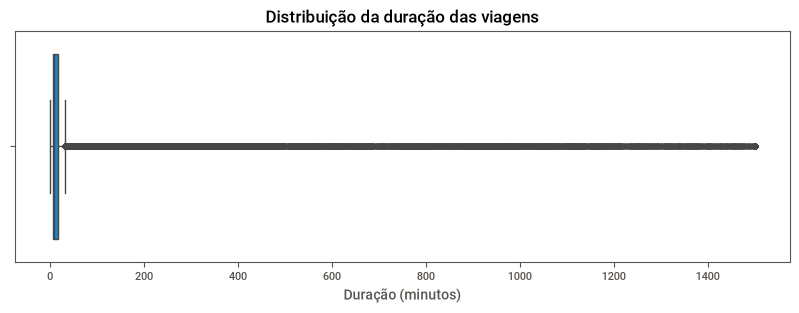

In [204]:
# Visualiza a distribuição da duração das viagens

plt.figure(figsize=(10, 3))

sns.boxplot(x=ride_length_minutes)

plt.title("Distribuição da duração das viagens")
plt.xlabel("Duração (minutos)")

plt.show()

In [205]:
# Calcula os quartis e o intervalo interquartil

Q1 = ride_length_minutes.quantile(0.25)
Q3 = ride_length_minutes.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [206]:
print(f"Q1: {Q1:.2f} minutos")
print(f"Q3: {Q3:.2f} minutos")
print(f"IQR: {IQR:.2f} minutos")
print(f"Limite inferior: {limite_inferior:.2f} minutos")
print(f"Limite superior: {limite_superior:.2f} minutos")

Q1: 5.33 minutos
Q3: 16.13 minutos
IQR: 10.80 minutos
Limite inferior: -10.88 minutos
Limite superior: 32.34 minutos


In [207]:
# Identifica os candidatos a outliers pelo critério do IQR

outliers_ride_length = ride_length_minutes > limite_superior

print(f"Quantidade de candidatos: {outliers_ride_length.sum():,}")
print(f"Percentual: {outliers_ride_length.mean() * 100:.2f}%")

Quantidade de candidatos: 423,123
Percentual: 6.92%


In [209]:
# Exibe as 20 maiores durações das viagens

display(
    df.loc[
        ride_length_minutes.nlargest(20).index,
        ["started_at", "ended_at", "ride_length", "member_casual"]
    ]
    .sort_values("ride_length", ascending=False)
)

,started_at,ended_at,ride_length,member_casual
6030783,2026-08-05 17:05:37.190,2026-08-06 18:05:35.867,1 days 00:59:58.677000,member
2164432,2026-02-23 17:13:15.307,2026-02-24 18:13:12.829,1 days 00:59:57.522000,member
1179858,2025-10-05 02:31:08.334,2025-10-06 03:31:05.649,1 days 00:59:57.315000,casual
3281065,2026-05-20 17:09:40.906,2026-05-21 18:09:38.122,1 days 00:59:57.216000,casual
1433609,2025-11-16 18:29:34.644,2025-11-17 19:29:31.784,1 days 00:59:57.140000,casual
6030727,2026-08-22 12:03:09.339,2026-08-23 13:03:06.438,1 days 00:59:57.099000,casual
1390234,2025-11-16 13:44:35.456,2025-11-17 14:44:32.500,1 days 00:59:57.044000,casual
4921914,2026-07-03 10:51:49.471,2026-07-04 11:51:46.291,1 days 00:59:56.820000,member
6084862,2026-08-21 08:05:07.934,2026-08-22 09:05:04.079,1 days 00:59:56.145000,member
2241594,2026-03-08 11:55:35.229,2026-03-09 12:55:30.744,1 days 00:59:55.515000,member


In [210]:
# Verifica a quantidade de viagens acima de diferentes durações

for limit in [60, 120, 300, 600]:
    count = (ride_length_minutes > limit).sum()
    percentage = count / len(df) * 100
    
    print(f"Acima de {limit} minutos: {count:,} ({percentage:.2f}%)")

Acima de 60 minutos: 108,796 (1.78%)
Acima de 120 minutos: 24,755 (0.41%)
Acima de 300 minutos: 4,922 (0.08%)
Acima de 600 minutos: 2,765 (0.05%)


In [211]:
# Analisa a distribuição das viagens com duração superior a 10 horas

extreme_ranges = pd.cut(
    ride_length_minutes[ride_length_minutes > 600],
    bins=[600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500],
    include_lowest=True
)

display(
    extreme_ranges
    .value_counts()
    .sort_index()
    .to_frame("Quantidade")
)

,Quantidade
ride_length,
"(599.999, 700.0]",352
"(700.0, 800.0]",313
"(800.0, 900.0]",338
"(900.0, 1000.0]",399
"(1000.0, 1100.0]",327
"(1100.0, 1200.0]",323
"(1200.0, 1300.0]",233
"(1300.0, 1400.0]",227
"(1400.0, 1500.0]",253


In [214]:
# Identifica viagens com duração superior a 24 horas

outliers_24h = ride_length_minutes > 1440

print(f"Quantidade de registros: {outliers_24h.sum():,}")
print(f"Percentual: {outliers_24h.mean() * 100:.4f}%")

Quantidade de registros: 174
Percentual: 0.0028%


In [215]:
display(
    df.loc[
        outliers_24h,
        ["started_at", "ended_at", "ride_length", "member_casual"]
    ]
    .sort_values("ride_length", ascending=False)
)

,started_at,ended_at,ride_length,member_casual
6030783,2026-08-05 17:05:37.190,2026-08-06 18:05:35.867,1 days 00:59:58.677000,member
2164432,2026-02-23 17:13:15.307,2026-02-24 18:13:12.829,1 days 00:59:57.522000,member
1179858,2025-10-05 02:31:08.334,2025-10-06 03:31:05.649,1 days 00:59:57.315000,casual
3281065,2026-05-20 17:09:40.906,2026-05-21 18:09:38.122,1 days 00:59:57.216000,casual
1433609,2025-11-16 18:29:34.644,2025-11-17 19:29:31.784,1 days 00:59:57.140000,casual
...,...,...,...,...
151008,2025-09-20 16:01:45.725,2025-09-21 16:03:19.075,1 days 00:01:33.350000,casual
1969802,2026-01-29 12:12:03.847,2026-01-30 12:13:22.817,1 days 00:01:18.970000,member
4662814,2026-06-30 18:03:01.787,2026-07-01 18:03:23.413,1 days 00:00:21.626000,casual
5639637,2026-08-12 01:22:00.873,2026-08-13 01:22:10.456,1 days 00:00:09.583000,casual


### Tratamento dos valores extremos

A análise da duração das viagens identificou uma distribuição assimétrica, com grande concentração de viagens curtas. Por esse motivo, o critério do IQR classificou 423.123 registros (6,92%) como candidatos a outliers. Entretanto, esses valores não foram considerados inválidos apenas por serem estatisticamente extremos, pois viagens com duração superior a 32 minutos ainda podem representar comportamentos reais dos usuários.

Durante a investigação, observou-se que 174 viagens apresentavam duração superior a 24 horas, correspondendo a apenas 0,0028% do dataset. Esse limite foi adotado como critério de tratamento por representar uma duração excepcionalmente elevada para uma viagem de bicicleta compartilhada e por reduzir o risco de manter registros decorrentes de viagens que permaneceram abertas ou de problemas no registro da devolução.

Assim, viagens com duração **igual ou inferior a 24 horas serão mantidas**, mesmo quando consideradas outliers pelo critério do IQR. Apenas os registros com duração **superior a 24 horas serão removidos**.

### 10.2 Remoção de Outlier de Duração de Viajens 

In [217]:
# Remove viagens com duração superior a 24 horas

df = df[ride_length_minutes <= 1440].copy()

In [218]:
# Verifica a quantidade de registros após a remoção dos valores extremos

print(f"Total de registros: {len(df):,}")

Total de registros: 6,110,353


In [219]:
# Recalcula a duração em minutos após o tratamento

ride_length_minutes = df["ride_length"].dt.total_seconds() / 60

print(f"Viagens acima de 24 horas: {(ride_length_minutes > 1440).sum()}")

Viagens acima de 24 horas: 0


##### Feedback da Remoção

-  Os registros com viajens com mais de 24 horas foram removidos com sucesso. Foram 174 registrosremovidos, apenas 0.0028% dos registros.